# Preparacao dos Dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from google.colab import files

print("Por favor, selecione o arquivo 'student_exam_performance_dataset.csv' no seu computador:")
arquivo_carregado = files.upload()

for nome_arquivo in arquivo_carregado.keys():
    print(f"O arquivo '{nome_arquivo}' foi carregado com sucesso!")


Por favor, selecione o arquivo 'student_exam_performance_dataset.csv' no seu computador:


Saving student_exam_performance_dataset.csv to student_exam_performance_dataset (2).csv
O arquivo 'student_exam_performance_dataset (2).csv' foi carregado com sucesso!


In [ ]:

df = pd.read_csv('student_exam_performance_dataset.csv')

# 2. Remoção de identificadores e prevenção de vazamento de dados
df_filtrado = df.drop(columns=['student_id', 'final_exam_score', 'pass_fail'])

# 3. Codificação de Variáveis Categóricas
le = LabelEncoder()
colunas_categoricas = ['gender', 'parental_education', 'family_income',
                       'internet_access', 'study_environment', 'tutoring']

for coluna in colunas_categoricas:
    df_filtrado[coluna] = le.fit_transform(df_filtrado[coluna])

# 4. Separação entre Previsores (X) e Alvo (y) e Divisão Treino/Teste
X = df_filtrado.drop(columns=['grade_category'])
y = df_filtrado['grade_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 5. Padronização e Ajuste de Escala
scaler = StandardScaler()
colunas_numericas = X.select_dtypes(include=[np.number]).columns.tolist()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test_scaled[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

print("Dados preparados com sucesso para o KNN!")

Dados preparados com sucesso para o KNN!


# KNN

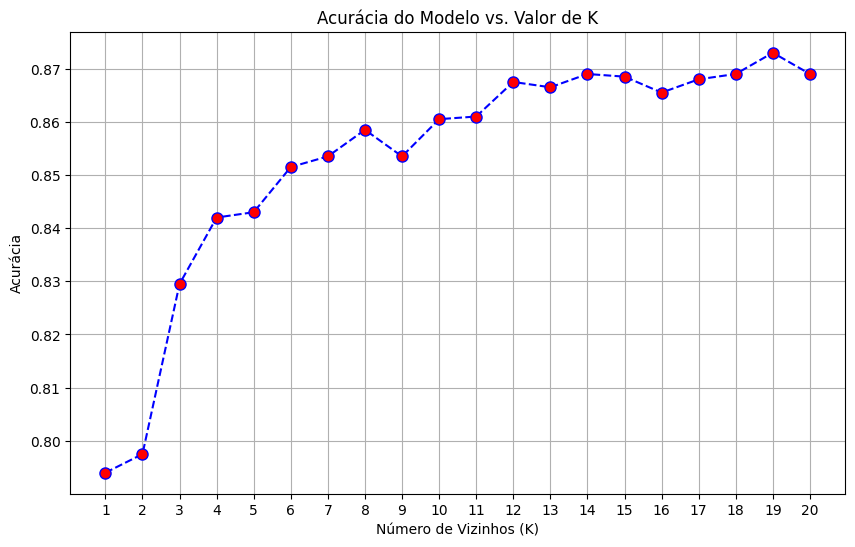

Com base na análise, o melhor valor para K é: 19


In [ ]:
# Lista para armazenar as taxas de acurácia de cada valor de K
acuracias = []
valores_k = range(1, 21)

# Testando o modelo para cada quantidade de vizinhos
for k in valores_k:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    previsoes_temp = knn_temp.predict(X_test_scaled)
    acuracia = accuracy_score(y_test, previsoes_temp)
    acuracias.append(acuracia)

# Plotando o gráfico de desempenho
plt.figure(figsize=(10, 6))
plt.plot(valores_k, acuracias, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Acurácia do Modelo vs. Valor de K')
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('Acurácia')
plt.xticks(valores_k)
plt.grid(True)
plt.show()

# Identificando o melhor K automaticamente
melhor_k = valores_k[np.argmax(acuracias)]
print(f"Com base na análise, o melhor valor para K é: {melhor_k}")

In [ ]:
# Instanciando o modelo com o melhor valor de K encontrado
modelo_knn_final = KNeighborsClassifier(9)

# Realizando o treinamento definitivo
modelo_knn_final.fit(X_train_scaled, y_train)

# Gerando as previsões oficiais para os alunos do conjunto de teste
previsoes_finais_knn = modelo_knn_final.predict(X_test_scaled)

print("Treinamento concluído e previsões geradas com sucesso!")

Treinamento concluído e previsões geradas com sucesso!


Acurácia Final do KNN: 87.30%

Relatório de Classificação:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         2
           B       0.33      0.06      0.10        17
           C       0.84      0.52      0.65       181
           D       0.81      0.90      0.85       766
           F       0.93      0.93      0.93      1034

    accuracy                           0.87      2000
   macro avg       0.58      0.48      0.51      2000
weighted avg       0.87      0.87      0.87      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


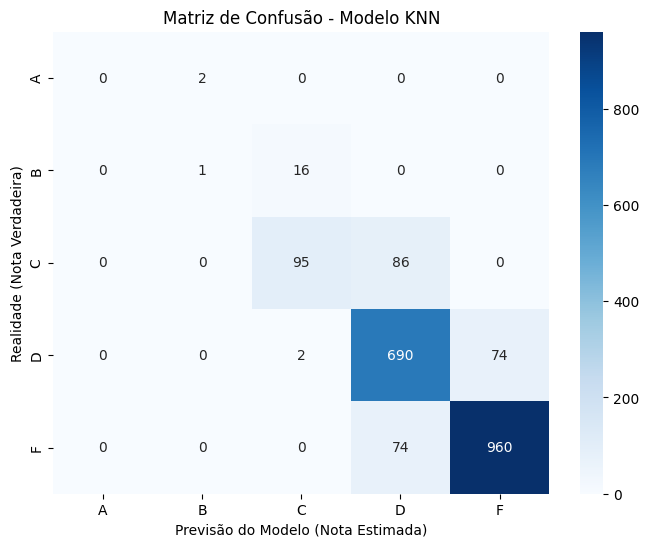

In [ ]:
# 1. Calculando e exibindo a Acurácia Global
acuracia_final = accuracy_score(y_test, previsoes_finais_knn)
print(f"Acurácia Final do KNN: {acuracia_final * 100:.2f}%\n")

# 2. Exibindo o Relatório de Classificação Detalhado
print("Relatório de Classificação:")
print(classification_report(y_test, previsoes_finais_knn))

# 3. Criando a Matriz de Confusão Visual
matriz_confusao = confusion_matrix(y_test, previsoes_finais_knn)

# Configurando as labels na ordem correta das notas
labels_notas = ['A', 'B', 'C', 'D', 'F']

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_notas, yticklabels=labels_notas)
plt.title('Matriz de Confusão - Modelo KNN')
plt.xlabel('Previsão do Modelo (Nota Estimada)')
plt.ylabel('Realidade (Nota Verdadeira)')
plt.show()

In [ ]:
# 1. Selecionando uma amostra aleatória de 5 alunos do nosso conjunto de teste
# O 'random_state' garante que pegaremos alunos diferentes de forma aleatória
amostra_indices = X_test.sample(35, random_state=55).index

# 2. Resgatando os dados originais (sem codificação) direto do DataFrame inicial
df_amostra = df.loc[amostra_indices].copy()

# 3. Pegando os dados padronizados (scaled) correspondentes a esses mesmos alunos para o modelo ler
X_amostra_scaled = X_test_scaled.loc[amostra_indices]

# 4. Pedindo para o modelo prever a nota apenas desses 5 alunos
previsoes_amostra = modelo_knn_final.predict(X_amostra_scaled)

# 5. Adicionando a previsão do modelo como uma nova coluna para comparação
df_amostra['previsao_do_modelo'] = previsoes_amostra

# 6. Selecionando apenas as colunas mais interessantes para visualizarmos na tela
colunas_visualizacao = [
    'study_hours_per_day',
    'sleep_hours',
    'social_media_hours',
    'attendance_rate',
    'grade_category', # A nota real do aluno
    'previsao_do_modelo' # O que o modelo achou que seria
]

# Exibindo a tabela final
print("--- Comparativo: Perfil do Aluno vs Previsão do Modelo ---")
display(df_amostra[colunas_visualizacao])

--- Comparativo: Perfil do Aluno vs Previsão do Modelo ---


,study_hours_per_day,sleep_hours,social_media_hours,attendance_rate,grade_category,previsao_do_modelo
2449,2.44,6.79,4.7,74.2,F,F
9783,0.50,8.22,2.0,86.3,F,F
6215,3.45,7.14,1.4,84.7,F,F
7738,3.26,6.59,2.8,71.1,D,F
8677,1.62,4.77,2.1,75.4,F,F
7309,3.46,7.18,3.0,92.7,F,D
2903,4.87,6.11,0.8,86.9,D,D
7608,3.90,8.47,1.4,76.6,D,D
6053,4.40,7.66,0.4,86.1,D,D
8534,3.27,8.11,2.6,80.4,D,D


# Naive Bayes

Acurácia Final do Naive Bayes: 90.50%

Relatório de Classificação - Naive Bayes:
              precision    recall  f1-score   support

           A       0.20      1.00      0.33         2
           B       0.57      0.47      0.52        17
           C       0.80      0.83      0.82       181
           D       0.86      0.92      0.89       766
           F       0.97      0.91      0.94      1034

    accuracy                           0.91      2000
   macro avg       0.68      0.83      0.70      2000
weighted avg       0.91      0.91      0.91      2000



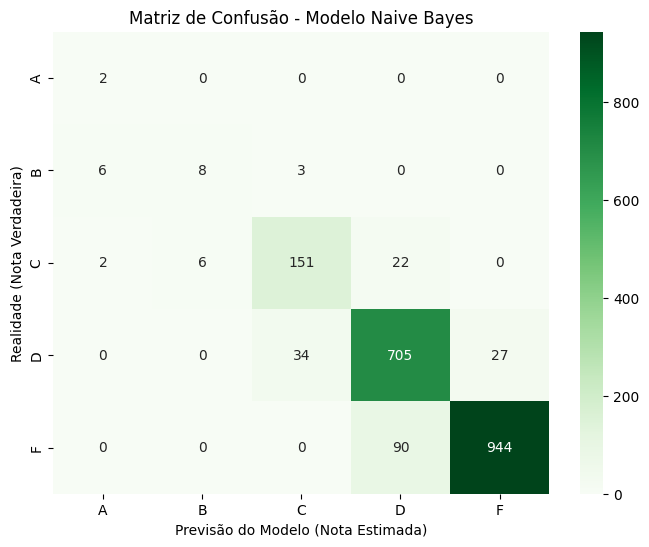

In [ ]:
from sklearn.naive_bayes import GaussianNB

# 1. Instanciando o modelo Naive Bayes Gaussiano
modelo_nb_final = GaussianNB()

# 2. Treinando o modelo com a mesma base de dados padronizada
modelo_nb_final.fit(X_train_scaled, y_train)

# 3. Gerando as previsões oficiais para os alunos do conjunto de teste
previsoes_finais_nb = modelo_nb_final.predict(X_test_scaled)

# 4. Calculando e exibindo a Acurácia Global do Naive Bayes
acuracia_final_nb = accuracy_score(y_test, previsoes_finais_nb)
print(f"Acurácia Final do Naive Bayes: {acuracia_final_nb * 100:.2f}%\n")

# 5. Exibindo o Relatório de Classificação Detalhado
print("Relatório de Classificação - Naive Bayes:")
print(classification_report(y_test, previsoes_finais_nb))

# 6. Criando a Matriz de Confusão Visual (em tons de verde para diferenciar)
matriz_confusao_nb = confusion_matrix(y_test, previsoes_finais_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_notas, yticklabels=labels_notas)
plt.title('Matriz de Confusão - Modelo Naive Bayes')
plt.xlabel('Previsão do Modelo (Nota Estimada)')
plt.ylabel('Realidade (Nota Verdadeira)')
plt.show()

In [ ]:
# 1. Selecionando uma amostra de 10 estudantes do conjunto de teste para inspeção
# O random_state=42 garante que nós pegaremos sempre os mesmos 10 alunos para facilitar a análise
amostra_indices = X_test.sample(25, random_state=42).index

# 2. Resgatando os dados originais textuais (da base bruta carregada no início)
df_inspecao = df.loc[amostra_indices].copy()

# 3. Isolando os dados padronizados equivalentes para que os modelos leiam
X_inspecao_scaled = X_test_scaled.loc[amostra_indices]

# 4. Solicitando as predições cegas apenas para o KNN e o Naive Bayes
df_inspecao['PREVISAO_KNN'] = modelo_knn_final.predict(X_inspecao_scaled)
df_inspecao['PREVISAO_NB'] = modelo_nb_final.predict(X_inspecao_scaled)

# 5. Selecionando as colunas de hábitos e as predições para exibição limpa
colunas_exibicao = [
    'study_hours_per_day',
    'sleep_hours',
    'social_media_hours',
    'attendance_rate',
    'grade_category',    # A nota real do aluno (nosso gabarito)
    'PREVISAO_KNN',      # O palpite do modelo baseado em distâncias
    'PREVISAO_NB'        # O palpite do modelo baseado em probabilidade
]

# 6. Exibindo a tabela formatada na tela do Colab
print("--- MAPEAMENTO DE PREVISÕES: KNN vs NAIVE BAYES ---")
display(df_inspecao[colunas_exibicao])

--- MAPEAMENTO DE PREVISÕES: KNN vs NAIVE BAYES ---


,study_hours_per_day,sleep_hours,social_media_hours,attendance_rate,grade_category,PREVISAO_KNN,PREVISAO_NB
949,3.62,7.12,3.0,82.7,D,D,D
466,3.04,5.87,4.0,90.8,D,F,D
7903,0.66,7.03,4.5,82.9,F,F,F
2995,1.67,7.70,3.0,77.5,F,F,F
5300,3.31,7.37,2.2,81.7,F,F,F
2241,3.16,6.94,3.1,98.6,F,F,F
5484,2.19,6.93,5.8,100.0,F,F,F
4838,3.21,6.99,4.5,76.2,F,F,F
1614,0.50,7.73,2.9,78.9,F,F,F
5259,2.37,7.08,3.1,98.1,C,C,C


# Arvore de Decisão

Acurácia Final da Árvore de Decisão: 86.45%

Relatório de Classificação - Árvore de Decisão:
              precision    recall  f1-score   support

           A       0.33      0.50      0.40         2
           B       0.57      0.47      0.52        17
           C       0.76      0.74      0.75       181
           D       0.83      0.84      0.83       766
           F       0.92      0.91      0.91      1034

    accuracy                           0.86      2000
   macro avg       0.68      0.69      0.68      2000
weighted avg       0.86      0.86      0.86      2000



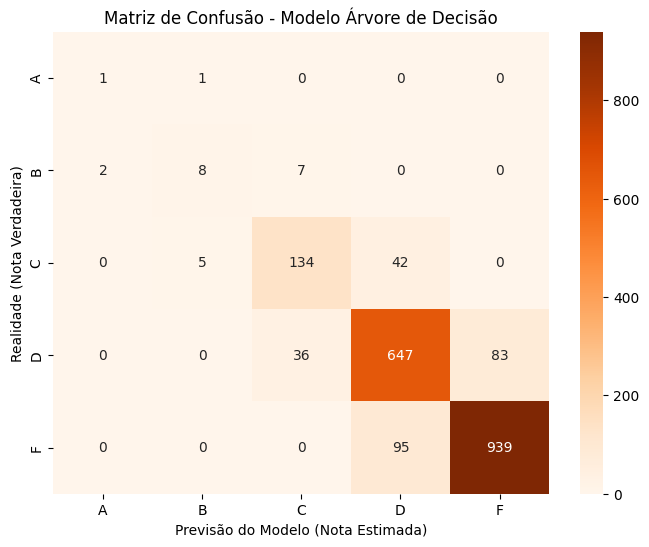

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 1. Instanciando o modelo de Árvore de Decisão
# O random_state=42 garante que os resultados sejam reproduzíveis e idênticos a cada execução
modelo_arvore_final = DecisionTreeClassifier(random_state=42)

# 2. Treinando o modelo com a mesma base de dados padronizada
modelo_arvore_final.fit(X_train_scaled, y_train)

# 3. Gerando as previsões oficiais para os alunos do conjunto de teste
previsoes_finais_arvore = modelo_arvore_final.predict(X_test_scaled)

# 4. Calculando e exibindo a Acurácia Global da Árvore de Decisão
acuracia_final_arvore = accuracy_score(y_test, previsoes_finais_arvore)
print(f"Acurácia Final da Árvore de Decisão: {acuracia_final_arvore * 100:.2f}%\n")

# 5. Exibindo o Relatório de Classificação Detalhado
print("Relatório de Classificação - Árvore de Decisão:")
print(classification_report(y_test, previsoes_finais_arvore))

# 6. Criando a Matriz de Confusão Visual
# Usando a cor 'Oranges' para manter o padrão visual diferenciado (KNN=Azul, NB=Verde)
matriz_confusao_arvore = confusion_matrix(y_test, previsoes_finais_arvore)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao_arvore, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_notas, yticklabels=labels_notas)
plt.title('Matriz de Confusão - Modelo Árvore de Decisão')
plt.xlabel('Previsão do Modelo (Nota Estimada)')
plt.ylabel('Realidade (Nota Verdadeira)')
plt.show()

In [ ]:
# 1. Selecionando uma amostra de 25 estudantes do conjunto de teste para inspeção
# O random_state=42 garante que nós pegaremos sempre os mesmos 25 alunos para facilitar a análise
amostra_indices = X_test.sample(25, random_state=42).index

# 2. Resgatando os dados originais textuais (da base bruta carregada no início)
df_inspecao = df.loc[amostra_indices].copy()

# 3. Isolando os dados padronizados equivalentes para que os modelos leiam
X_inspecao_scaled = X_test_scaled.loc[amostra_indices]

# 4. Solicitando as predições cegas para o KNN, Naive Bayes e Árvore de Decisão
df_inspecao['PREVISAO_KNN'] = modelo_knn_final.predict(X_inspecao_scaled)
df_inspecao['PREVISAO_NB'] = modelo_nb_final.predict(X_inspecao_scaled)
df_inspecao['PREVISAO_ARVORE'] = modelo_arvore_final.predict(X_inspecao_scaled)

# 5. Selecionando as colunas de hábitos e as predições para exibição limpa
colunas_exibicao = [
    'study_hours_per_day',
    'sleep_hours',
    'social_media_hours',
    'attendance_rate',
    'grade_category',    # A nota real do aluno (nosso gabarito)
    'PREVISAO_KNN',      # O palpite do modelo baseado em distâncias
    'PREVISAO_NB',       # O palpite do modelo baseado em probabilidade
    'PREVISAO_ARVORE'    # O palpite do modelo baseado em regras condicionais
]

# 6. Exibindo a tabela formatada na tela do Colab
print("--- MAPEAMENTO DE PREVISÕES: KNN vs NAIVE BAYES vs ÁRVORE DE DECISÃO ---")
display(df_inspecao[colunas_exibicao])

--- MAPEAMENTO DE PREVISÕES: KNN vs NAIVE BAYES vs ÁRVORE DE DECISÃO ---


,study_hours_per_day,sleep_hours,social_media_hours,attendance_rate,grade_category,PREVISAO_KNN,PREVISAO_NB,PREVISAO_ARVORE
949,3.62,7.12,3.0,82.7,D,D,D,D
466,3.04,5.87,4.0,90.8,D,F,D,D
7903,0.66,7.03,4.5,82.9,F,F,F,F
2995,1.67,7.70,3.0,77.5,F,F,F,F
5300,3.31,7.37,2.2,81.7,F,F,F,F
2241,3.16,6.94,3.1,98.6,F,F,F,F
5484,2.19,6.93,5.8,100.0,F,F,F,F
4838,3.21,6.99,4.5,76.2,F,F,F,F
1614,0.50,7.73,2.9,78.9,F,F,F,F
5259,2.37,7.08,3.1,98.1,C,C,C,C


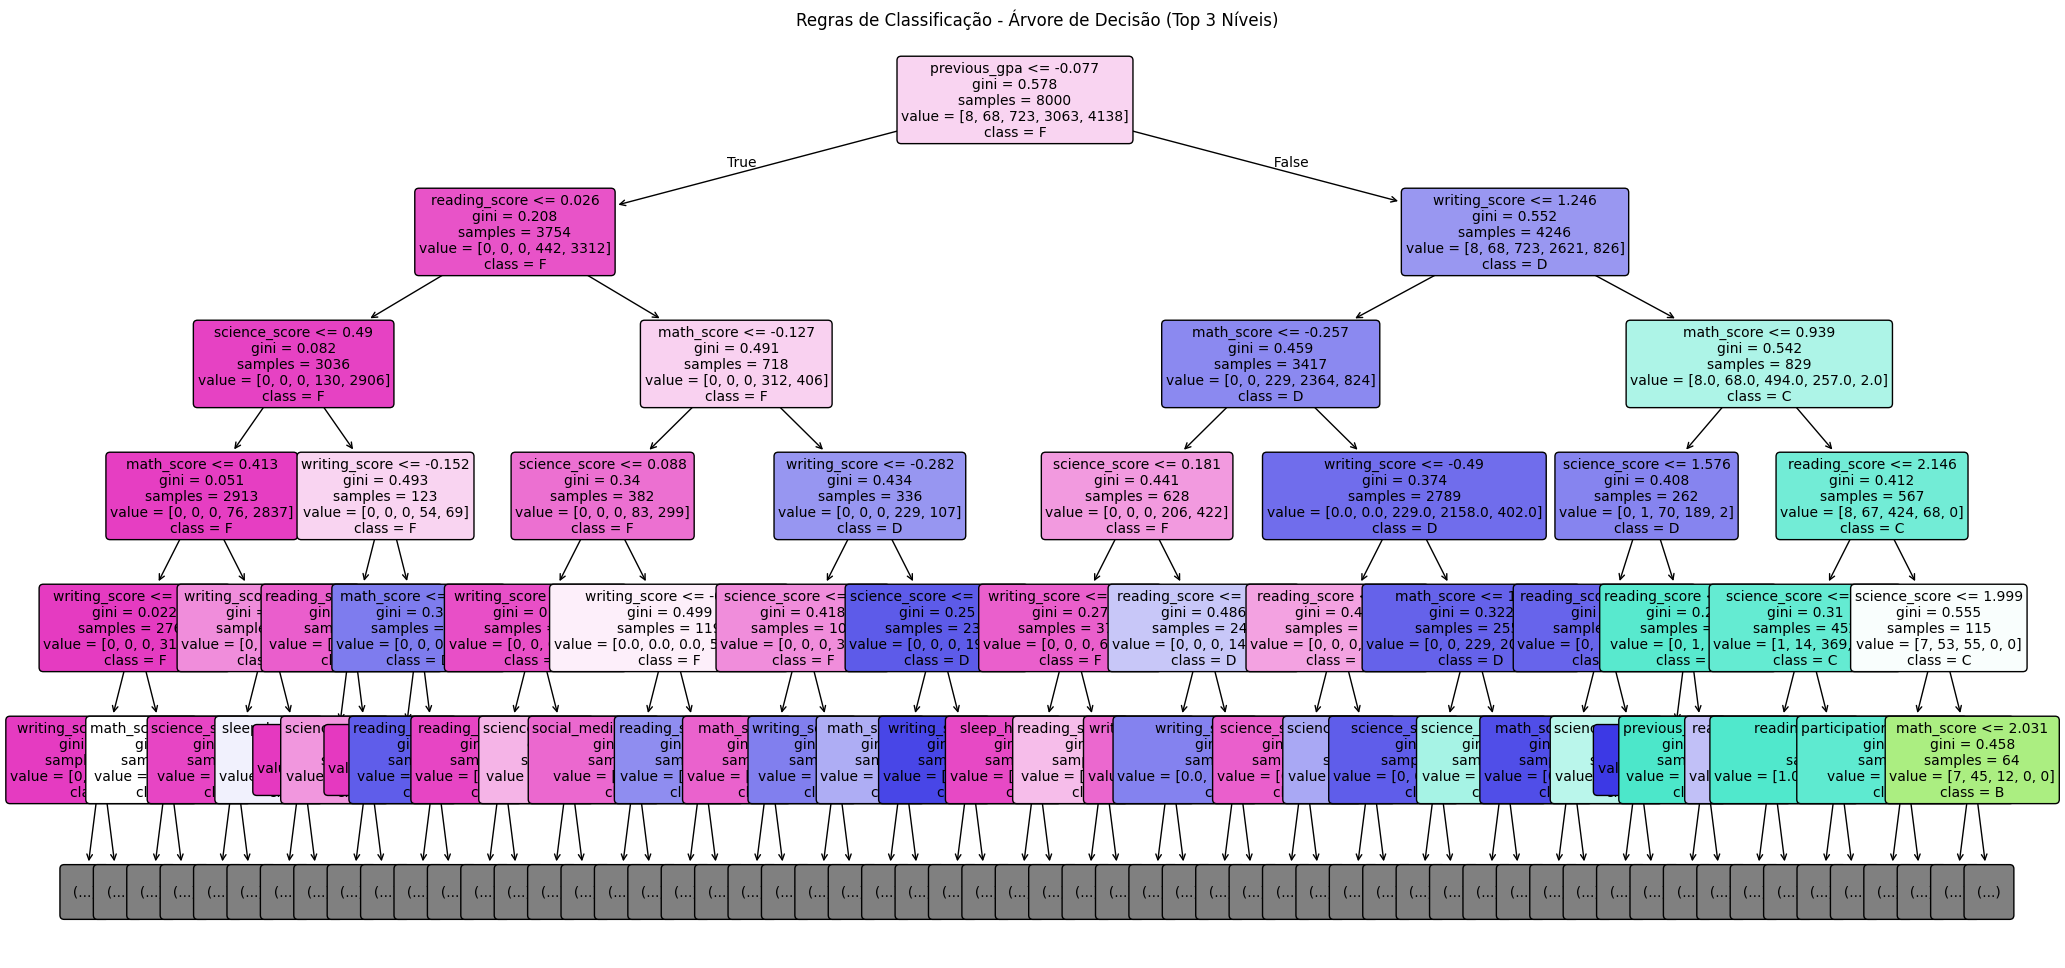

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configurando o tamanho da tela (ajuste os valores se precisar de mais espaço)
plt.figure(figsize=(25, 12))

# Desenhando a árvore de decisão
plot_tree(modelo_arvore_final,
          feature_names=X.columns,               # Nome das colunas (hábitos dos alunos)
          class_names=modelo_arvore_final.classes_, # Nome das classes (notas A, B, C, D, F)
          filled=True,                           # Pinta os blocos de acordo com a classe dominante
          rounded=True,                          # Deixa as caixas com bordas arredondadas
          max_depth=5,                           # Limita a visualização para não virar um "borrão"
          fontsize=10)

plt.title('Regras de Classificação - Árvore de Decisão (Top 3 Níveis)')
plt.show()

# Criando o Comite

In [ ]:
from sklearn.ensemble import VotingClassifier

# 1. Criando o Comitê com votação por maioria (hard voting)
modelo_comite = VotingClassifier(
    estimators=[
        ('KNN', modelo_knn_final),
        ('Naive Bayes', modelo_nb_final),
        ('Arvore', modelo_arvore_final)
    ],
    voting='hard' # 'hard' significa que a decisão será tomada por maioria simples de votos
)

# 2. Treinando o comitê na base de dados
modelo_comite.fit(X_train_scaled, y_train)

# 3. Gerando as previsões do comitê para o conjunto de teste
previsoes_finais_comite = modelo_comite.predict(X_test_scaled)

# 4. Calculando e exibindo a Acurácia Global do Comitê
acuracia_final_comite = accuracy_score(y_test, previsoes_finais_comite)
print(f"Acurácia Final do Comitê: {acuracia_final_comite * 100:.2f}%\n")

# 5. Exibindo o Relatório de Classificação Detalhado
print("Relatório de Classificação - Comitê:")
print(classification_report(y_test, previsoes_finais_comite))

# Adicionando o veredito final do comitê na nossa tabela de amostra
df_inspecao['VOTO_FINAL_COMITE'] = modelo_comite.predict(X_inspecao_scaled)

# Selecionando todas as colunas para a exibição final
colunas_exibicao_comite = [
    'study_hours_per_day',
    'sleep_hours',
    'social_media_hours',
    'attendance_rate',
    'grade_category',
    'PREVISAO_KNN',      # Voto 1
    'PREVISAO_NB',       # Voto 2
    'PREVISAO_ARVORE',   # Voto 3
    'VOTO_FINAL_COMITE'  # A Decisão da Maioria
]

print("\n--- MAPEAMENTO DE PREVISÕES: O TRIBUNAL DO COMITÊ ---")
display(df_inspecao[colunas_exibicao_comite])

Acurácia Final do Comitê: 89.85%

Relatório de Classificação - Comitê:
              precision    recall  f1-score   support

           A       0.33      0.50      0.40         2
           B       0.64      0.41      0.50        17
           C       0.81      0.76      0.78       181
           D       0.86      0.90      0.88       766
           F       0.95      0.93      0.94      1034

    accuracy                           0.90      2000
   macro avg       0.72      0.70      0.70      2000
weighted avg       0.90      0.90      0.90      2000


--- MAPEAMENTO DE PREVISÕES: O TRIBUNAL DO COMITÊ ---


,study_hours_per_day,sleep_hours,social_media_hours,attendance_rate,grade_category,PREVISAO_KNN,PREVISAO_NB,PREVISAO_ARVORE,VOTO_FINAL_COMITE
949,3.62,7.12,3.0,82.7,D,D,D,D,D
466,3.04,5.87,4.0,90.8,D,F,D,D,D
7903,0.66,7.03,4.5,82.9,F,F,F,F,F
2995,1.67,7.70,3.0,77.5,F,F,F,F,F
5300,3.31,7.37,2.2,81.7,F,F,F,F,F
2241,3.16,6.94,3.1,98.6,F,F,F,F,F
5484,2.19,6.93,5.8,100.0,F,F,F,F,F
4838,3.21,6.99,4.5,76.2,F,F,F,F,F
1614,0.50,7.73,2.9,78.9,F,F,F,F,F
5259,2.37,7.08,3.1,98.1,C,C,C,C,C


# Relatorio Final

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Garantindo que temos as previsões mais recentes de todos os modelos no conjunto de teste
y_pred_knn = modelo_knn_final.predict(X_test_scaled)
y_pred_nb = modelo_nb_final.predict(X_test_scaled)
y_pred_arvore = modelo_arvore_final.predict(X_test_scaled)
y_pred_comite = modelo_comite.predict(X_test_scaled)

# 2. Criando uma função auxiliar para calcular as 4 métricas principais de uma vez
# Usamos average='weighted' para que a média considere o volume de alunos em cada nota (A, B, C, D, F)
def calcular_metricas(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return [acc, prec, rec, f1]

# 3. Compilando os resultados em uma lista de listas (linhas da nossa tabela)
dados_relatorio = [
    ['KNN'] + calcular_metricas(y_test, y_pred_knn),
    ['Naive Bayes'] + calcular_metricas(y_test, y_pred_nb),
    ['Árvore de Decisão'] + calcular_metricas(y_test, y_pred_arvore),
    ['Comitê (Hard Voting)'] + calcular_metricas(y_test, y_pred_comite)
]

# 4. Transformando os dados em um DataFrame do Pandas
colunas_relatorio = ['Modelo', 'Acurácia', 'Precisão', 'Recall', 'F1-Score']
df_relatorio = pd.DataFrame(dados_relatorio, columns=colunas_relatorio)

# Colocando o nome do modelo como o índice (a primeira coluna em negrito) da tabela
df_relatorio.set_index('Modelo', inplace=True)

# 5. Formatando os números para aparecerem como porcentagem (ex: 85.50%)
df_relatorio_formatado = df_relatorio.style.format("{:.2%}").background_gradient(cmap='Blues')

# 6. Exibindo a tabela final
print("--- TABELA DE COMPARAÇÃO DE DESEMPENHO ---")
display(df_relatorio_formatado)

--- TABELA DE COMPARAÇÃO DE DESEMPENHO ---


,Acurácia,Precisão,Recall,F1-Score
Modelo,,,,
KNN,87.30%,86.98%,87.30%,86.64%
Naive Bayes,90.50%,91.09%,90.50%,90.68%
Árvore de Decisão,86.45%,86.48%,86.45%,86.45%
Comitê (Hard Voting),89.90%,90.11%,89.90%,89.86%
